# Drift correction (AIM)

Sample stages drift over the course of a long acquisition — a few hundred nanometres over
a movie is common — which smears out what should be tight, round single-molecule clusters
into streaks. `AnalysisPipeline.undrift(method="aim")` estimates and removes this drift by
splitting the movie into segments and tracking how the same molecules' apparent positions
shift segment-to-segment.

Data: `test_tiffs/drift_correction/` — 30 non-blinking, non-bleaching gold-nanoparticle
fiducials (always ON, ~10,000 photons/frame — much brighter than a real dye, matching how
fiducials read out), 300 frames, with a known **injected linear drift** of (0, 0) → (1000,
500) nm over the movie (`ground_truth/injected_drift_nm.npy`). Ground truth undrifted
positions are in `ground_truth/drift_correction_ground_truth.h5`.

**This notebook deliberately shows a wrong parameter choice first, then the right one** —
it's a real trade-off in how AIM works, not just a fixture quirk, and worth understanding
rather than memorising.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyS3M.AnalysisPipeline import AnalysisPipeline, FittingConfig
from pyS3M.Constants import AnalysisConfig
import pyS3M.PlottingBase as PlottingBase

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "test_tiffs" / "drift_correction"
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"

cfg = AnalysisConfig(display=False)
pipe = AnalysisPipeline(camera="ximea", config=cfg)
pipe.load_calibration(CALIBRATION_DIR)
plotter = PlottingBase.PublicationPlotter()

## Fit

Fiducials are simulated as an effective 561 nm point-scatterer source (see the fixture's own `README.md`).

In [2]:
fc = FittingConfig(peak_wavelength=0.561, pfa=1e-3)
pipe.fit(DATA_DIR, mode="smlm", fitting_config=fc)

locs = pipe.load_localisations(DATA_DIR)
print(f"{len(locs)} localisations, {locs['frame'].max() + 1} frames")

Detecting puncta:   0%|          | 0/300 [00:00<?, ?it/s]

8984 localisations, 300 frames


## Raw (drifted) render

30 fiducials, always on for all 300 frames — each one's apparent position should trace out
a ~1000/500 nm streak by the end of the movie rather than sitting still.

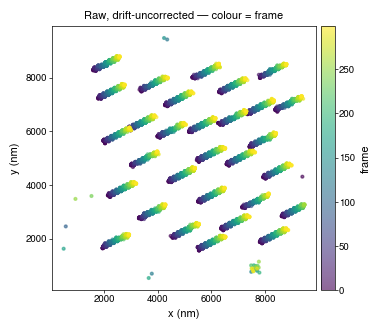

In [3]:
pixel_size_nm = pipe.pixel_size * 1000.0

fig, ax = plotter.create_figure()
# scatter_plot has no continuous-colormap option (single `color` only), so this one
# point -- colour-by-frame -- stays direct matplotlib; add_colorbar still standardises
# the colorbar itself.
sc = ax.scatter(locs["xc"] * pixel_size_nm, locs["yc"] * pixel_size_nm,
                 c=locs["frame"], cmap="viridis", s=4, alpha=0.6)
ax.set_aspect("equal")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title("Raw, drift-uncorrected — colour = frame")
plotter.add_colorbar(sc, ax, label="frame")
plt.show()

## Undrift, first attempt — `segmentation=100` (the panel's default)

`AnalysisPipeline.undrift` needs a Picasso-style `info` list (`Width`/`Height`/`Frames`/
`Pixelsize`) and a plain `np.recarray` rather than a DataFrame — matching exactly what the
GUI's Drift Correction panel does internally.

In [4]:
height, width = pipe.gain_map.shape[:2]
n_frames = int(locs["frame"].max()) + 1
info = [{"Width": int(width), "Height": int(height), "Frames": n_frames, "Pixelsize": pixel_size_nm}]
locs_rec = locs.to_records(index=False)

corrected_100, drift_100 = pipe.undrift(
    locs_rec, info, method="aim",
    segmentation=100, intersect_d=20.0 / pixel_size_nm, roi_r=60.0 / pixel_size_nm,
    pixel_size_nm=pixel_size_nm,
)
span_x_100 = drift_100.drift_x.max() - drift_100.drift_x.min()
span_y_100 = drift_100.drift_y.max() - drift_100.drift_y.min()
print(f"segmentation=100 recovered drift span: {span_x_100 * pixel_size_nm:.0f} / {span_y_100 * pixel_size_nm:.0f} nm")
print("Injected drift was 1000 / 500 nm — this badly underestimates it.")

AIM Undrifting (1/2):   0%|          | 0/2 [00:00<?, ?it/s]

AIM Undrifting (2/2):   0%|          | 0/3 [00:00<?, ?it/s]

segmentation=100 recovered drift span: 58 / 75 nm
Injected drift was 1000 / 500 nm — this badly underestimates it.


**Why**: AIM matches the same molecule between consecutive segments within a search
radius `roi_r` (default 60 nm). At this fixture's drift rate (~3.3/1.7 nm/frame x/y), a
100-frame segment accumulates ~333/167 nm of real drift — far past `roi_r`, so AIM loses
track of fiducials between segments and the recovered trace collapses to a small fraction
of the true drift. This isn't a bug in AIM or the fixture: **any** real dataset needs
`roi_r` scaled to `segmentation × drift rate`, or `segmentation` shortened until each
segment's drift fits inside `roi_r`.

## Undrift, second attempt — `segmentation=5`

A 5-frame segment only accumulates ~17/8 nm of drift, comfortably inside the default 60 nm
`roi_r`.

In [5]:
corrected_5, drift_5 = pipe.undrift(
    locs_rec, info, method="aim",
    segmentation=5, intersect_d=20.0 / pixel_size_nm, roi_r=60.0 / pixel_size_nm,
    pixel_size_nm=pixel_size_nm,
)
span_x_5 = drift_5.drift_x.max() - drift_5.drift_x.min()
span_y_5 = drift_5.drift_y.max() - drift_5.drift_y.min()
print(f"segmentation=5 recovered drift span: {span_x_5 * pixel_size_nm:.0f} / {span_y_5 * pixel_size_nm:.0f} nm")
print("Much closer to the injected 1000 / 500 nm.")

AIM Undrifting (1/2):   0%|          | 0/59 [00:00<?, ?it/s]

AIM Undrifting (1/2):  19%|█▊        | 11/59 [00:00<00:00, 217.36it/s]

AIM Undrifting (1/2):  27%|██▋       | 16/59 [00:00<00:00, 138.06it/s]

AIM Undrifting (1/2):  34%|███▍      | 20/59 [00:00<00:00, 111.37it/s]

AIM Undrifting (1/2):  41%|████      | 24/59 [00:00<00:00, 95.60it/s] 

...

AIM Undrifting (2/2):  83%|████████▎ | 50/60 [00:00<00:00, 64.74it/s]

AIM Undrifting (2/2):  88%|████████▊ | 53/60 [00:00<00:00, 62.81it/s]

AIM Undrifting (2/2):  93%|█████████▎| 56/60 [00:00<00:00, 59.92it/s]

AIM Undrifting (2/2):  98%|█████████▊| 59/60 [00:00<00:00, 59.50it/s]

segmentation=5 recovered drift span: 1002 / 492 nm
Much closer to the injected 1000 / 500 nm.


## Drift trace comparison

/tmp/ipykernel_2212307/1672695220.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


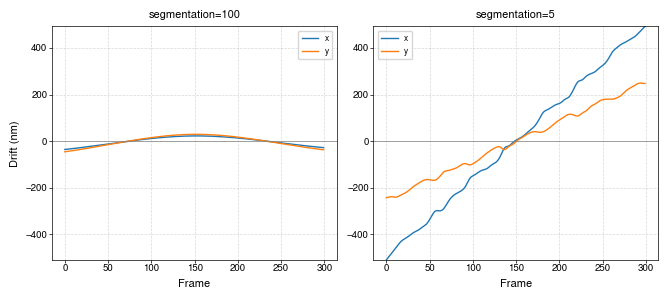

In [6]:
fig, axes = plotter.two_column_plot(nrows=1, ncols=2)
drifts = [drift_100, drift_5]
# two_column_plot has no sharey option (unlike plt.subplots) -- matched manually so the
# segmentation=100 vs segmentation=5 comparison stays visually apples-to-apples.
ylims = [pixel_size_nm * min(d.drift_x.min(), d.drift_y.min(), 0) for d in drifts]
ylims += [pixel_size_nm * max(d.drift_x.max(), d.drift_y.max(), 0) for d in drifts]
shared_ylim = (min(ylims), max(ylims))
for ax, drift, title in zip(axes, drifts, ["segmentation=100", "segmentation=5"]):
    frames = np.arange(len(drift.drift_x))
    plotter.line_plot(ax, frames, drift.drift_x * pixel_size_nm, ylabel="", color="tab:blue", label="x")
    plotter.line_plot(ax, frames, drift.drift_y * pixel_size_nm, ylabel="", color="tab:orange", label="y")
    ax.axhline(0, color="grey", lw=0.5)
    ax.set_xlabel("Frame")
    ax.set_title(title)
    ax.set_ylim(shared_ylim)
axes[0].set_ylabel("Drift (nm)")
plt.tight_layout()
plt.show()

## Before / after render (`segmentation=5`)

The corrected result should show tight, round fiducial clusters rather than the raw
render's streaks.

/tmp/ipykernel_2212307/2296018741.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


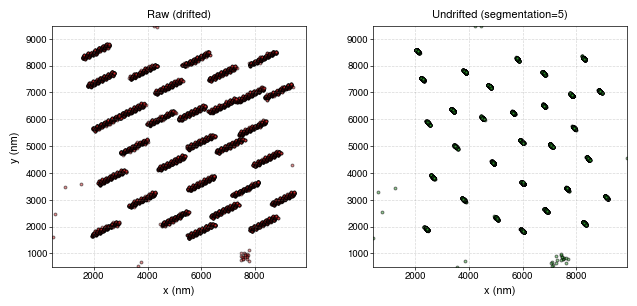

In [7]:
corrected_df = pd.DataFrame(corrected_5)

fig, axes = plotter.two_column_plot(nrows=1, ncols=2)
plotter.scatter_plot(axes[0], locs["xc"] * pixel_size_nm, locs["yc"] * pixel_size_nm,
                      ylabel="", color="tab:red", size=4, alpha=0.5)
axes[0].set_title("Raw (drifted)")
plotter.scatter_plot(axes[1], corrected_df["xc"] * pixel_size_nm, corrected_df["yc"] * pixel_size_nm,
                      ylabel="", color="tab:green", size=4, alpha=0.5)
axes[1].set_title("Undrifted (segmentation=5)")
# two_column_plot has no sharex/sharey option -- matched manually so raw-vs-corrected
# stays a fair visual comparison (not each panel auto-scaled to its own extent).
xs = pd.concat([locs["xc"], corrected_df["xc"]]) * pixel_size_nm
ys = pd.concat([locs["yc"], corrected_df["yc"]]) * pixel_size_nm
shared_xlim, shared_ylim = (xs.min(), xs.max()), (ys.min(), ys.max())
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x (nm)")
    ax.set_xlim(shared_xlim)
    ax.set_ylim(shared_ylim)
axes[0].set_ylabel("y (nm)")
plt.tight_layout()
plt.show()

## Next: `04_clustering_and_quality_filtering.ipynb`